# Análisis Exploratorio de Datos (EDA)

In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

# Cargar el Dataset
df = pd.read_csv('data/retailmax.csv')

# 1. ¿Cuál es la distribución de edades de los clientes?

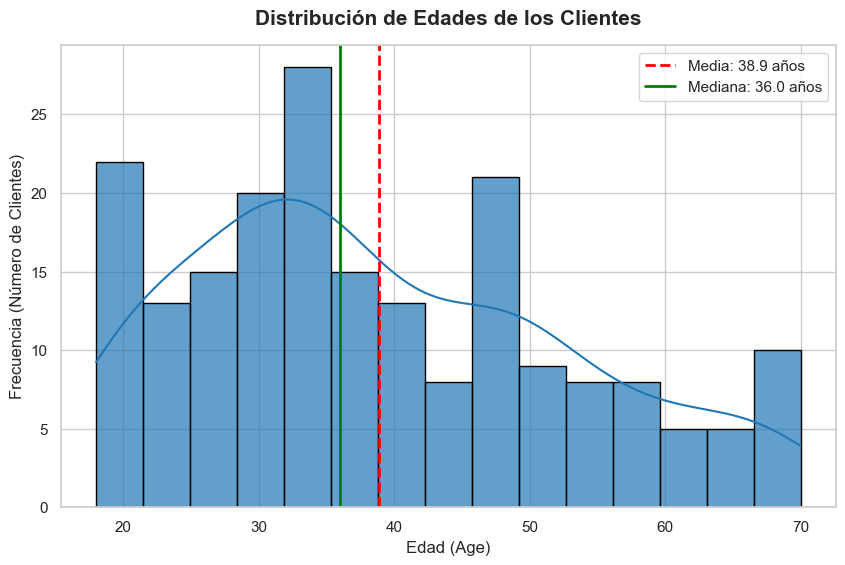

In [8]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=15, kde=True, color='#1f77b4', edgecolor='black', alpha=0.7)
plt.title('Distribución de Edades de los Clientes', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Frecuencia (Número de Clientes)', fontsize=12)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Age"].mean():.1f} años')
plt.axvline(df['Age'].median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {df["Age"].median():.1f} años')
plt.legend(fontsize=11)
plt.show()

# 2. ¿Existen diferencias en los ingresos anuales entre hombres y mujeres?

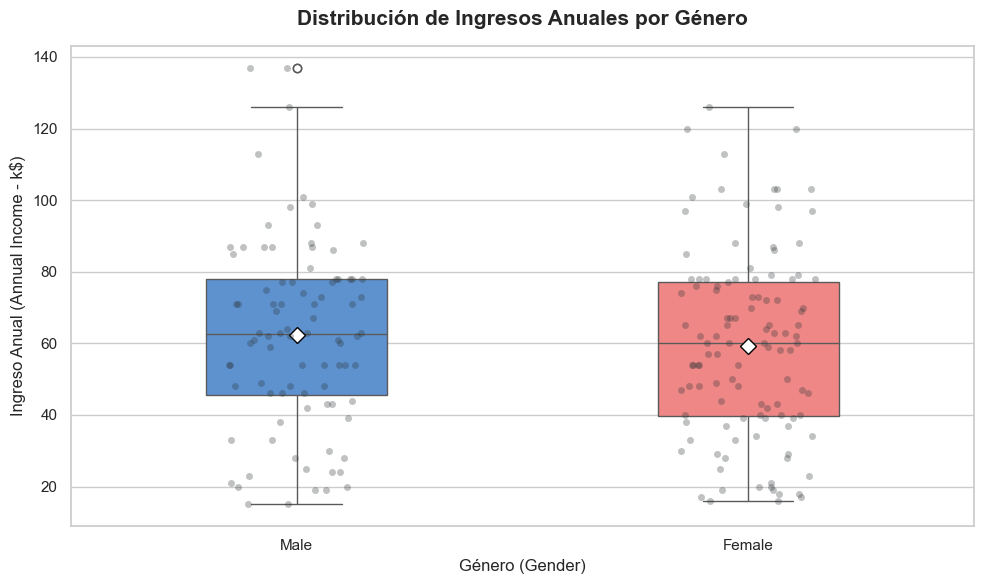

In [9]:
plt.figure(figsize=(10, 6))

# Gráfico de caja (boxplot) con strip plot superpuesto para ver la distribución individual
sns.boxplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    width=0.4,
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Mostrar los puntos individuales de datos de manera sutil
sns.stripplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    color='#2d3436', 
    alpha=0.3, 
    jitter=0.15, 
    size=5
)

plt.title('Distribución de Ingresos Anuales por Género', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Género (Gender)', fontsize=12)
plt.ylabel('Ingreso Anual (Annual Income - k$)', fontsize=12)

plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de ingresos anuales entre hombres y mujeres, observamos que **no existen diferencias drásticas**, aunque sí se aprecian ligeras variaciones a favor del grupo masculino:

1. **Promedio (Media) y Mediana:**
   - Los **hombres** tienen un ingreso anual promedio de **62.23 k$** y una mediana de **62.50 k$**.
   - Las **mujeres** tienen un ingreso anual promedio de **59.25 k$** y una mediana de **60.00 k$**.
   - Esto representa una ligera diferencia de **~2.98 k$ en la media** y **2.50 k$ en la mediana** a favor de los hombres.

2. **Dispersión y Límites:**
   - La dispersión (desviación estándar) es sumamente similar en ambos grupos: **26.64 k$** para hombres y **26.01 k$** para mujeres.
   - Los rangos intercuartílicos y las cajas en el gráfico muestran que el 50% central de la población se encuentra en rangos muy similares, aunque el límite inferior del 25% de los hombres (45.5 k$) es ligeramente mayor al de las mujeres (39.75 k$).
   - El ingreso máximo registrado pertenece a un hombre con **137 k$**, mientras que el de las mujeres es de **126 k$**.

**Conclusión:** Aunque estadísticamente los hombres muestran ingresos ligeramente superiores en términos de medidas de tendencia central (media y mediana) y valores máximos, las distribuciones se superponen en gran medida. Esto sugiere que **el género no es un factor determinante o altamente diferenciador** para el nivel de ingresos en este conjunto de datos.

# 3. ¿Cómo se distribuye la puntuación de gastos entre los diferentes rangos de edades?

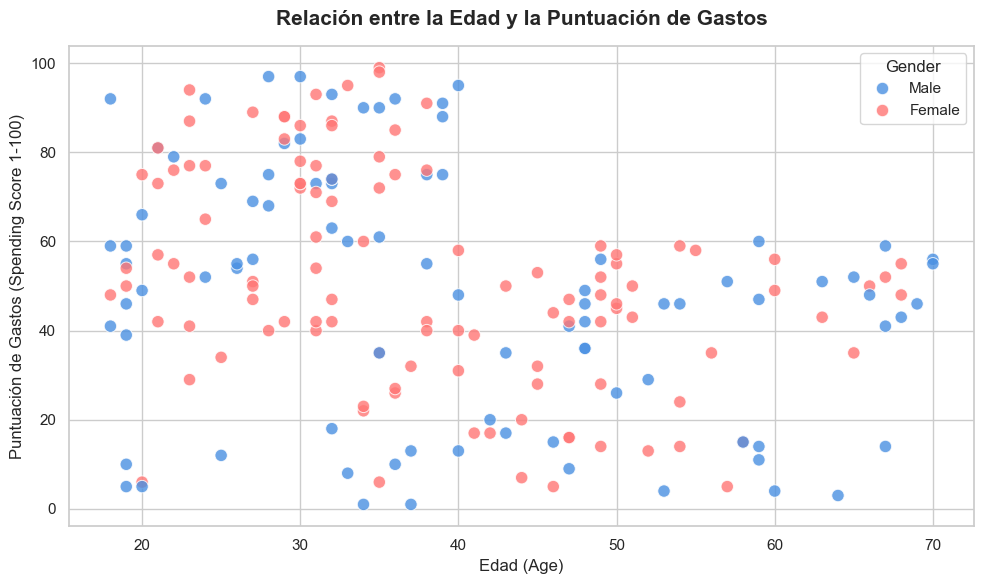

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score (1-100)',
    hue='Gender',
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    alpha=0.8,
    s=80
)

plt.title('Relación entre la Edad y la Puntuación de Gastos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Puntuación de Gastos (Spending Score 1-100)', fontsize=12)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de la puntuación de gastos (`Spending Score (1-100)`) en función de la edad (`Age`), podemos extraer conclusiones muy claras y valiosas sobre el comportamiento de los clientes:

1. **Límite de Edad para Altos Consumidores:**
   - Se observa una clara barrera alrededor de los **40 años**. Prácticamente **ningún cliente mayor de 40 años supera una puntuación de gasto de 60**.
   - La gran mayoría de los clientes de más de 40 años se concentra en un rango de puntuación moderado y bajo (entre 1 y 60 puntos), con una media que ronda los **32-34 puntos**.

2. **Comportamiento en Clientes Jóvenes (< 40 años):**
   - Los clientes de entre 18 y 40 años muestran una dispersión mucho mayor y son los únicos que alcanzan puntuaciones de gastos sobresalientes (entre 60 y 100 puntos).
   - En este segmento joven, se aprecian claramente dos grupos bien diferenciados: uno de perfil muy ahorrador/moderado (puntuaciones bajas) y otro de perfil altamente consumidor (puntuaciones que van de 60 a 99 puntos).

**Conclusión:** La edad es un factor altamente segmentador en este conjunto de datos. Mientras que los clientes jóvenes (< 40 años) presentan un grupo con potencial de compra sumamente elevado, el segmento de mayor edad (>= 40 años) exhibe un comportamiento de gasto mucho más moderado y homogéneo, sin superar nunca la franja alta de puntuación.

## 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?

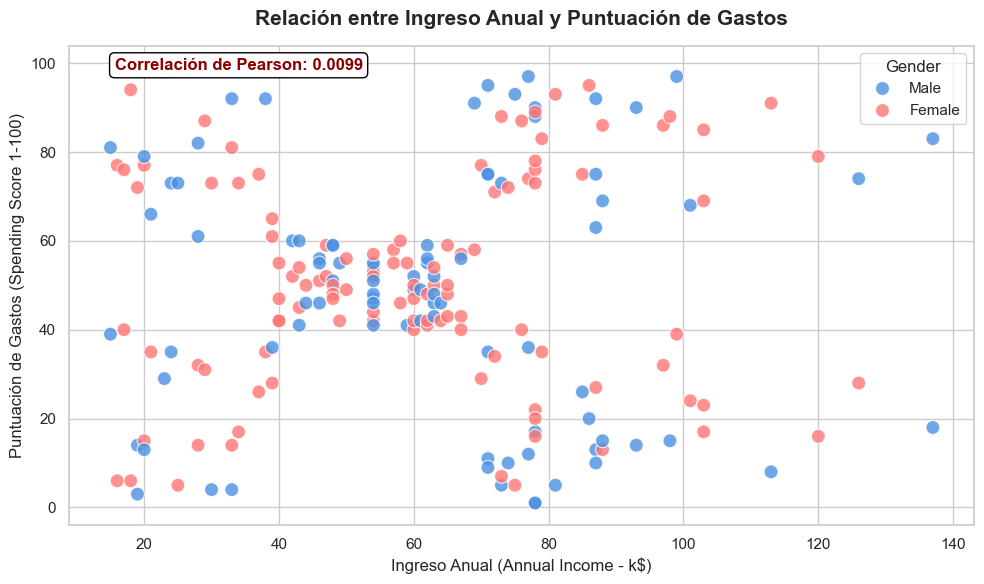

El coeficiente de correlación de Pearson es: 0.0099


In [11]:
# Calcular el coeficiente de correlación de Pearson
correlation = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])

# Configurar el lienzo de la gráfica
plt.figure(figsize=(10, 6))

# Crear el gráfico de dispersión (scatter plot)
sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Gender', 
    palette={'Male': '#4a90e2', 'Female': '#ff7675'}, 
    alpha=0.8, 
    s=100
)

# Añadir títulos y etiquetas
plt.title('Relación entre Ingreso Anual y Puntuación de Gastos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Ingreso Anual (Annual Income - k$)', fontsize=12)
plt.ylabel('Puntuación de Gastos (Spending Score 1-100)', fontsize=12)

# Mostrar el coeficiente de correlación en la gráfica
plt.annotate(f'Correlación de Pearson: {correlation:.4f}', 
             xy=(0.05, 0.95), xycoords='axes fraction', 
             fontsize=12, fontweight='bold', color='darkred',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.tight_layout()
plt.show()

print(f"El coeficiente de correlación de Pearson es: {correlation:.4f}")

## 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?

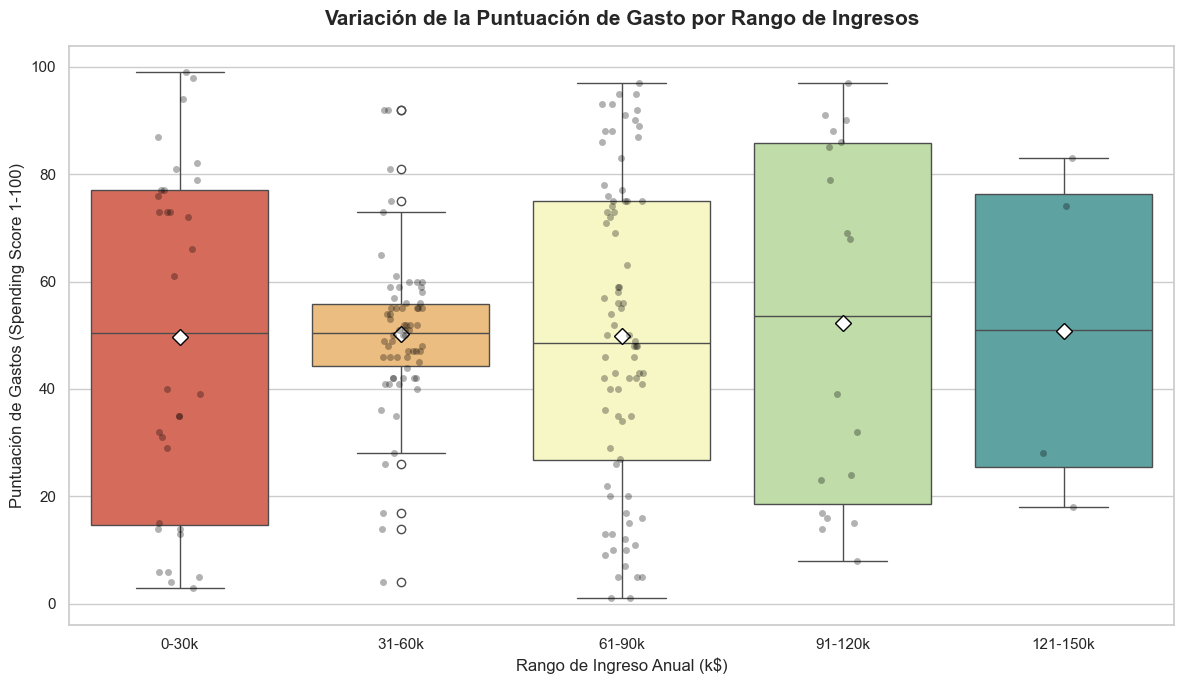

In [14]:
# Crear rangos de ingresos para facilitar la visualización
bins = [0, 30, 60, 90, 120, 150]
labels = ['0-30k', '31-60k', '61-90k', '91-120k', '121-150k']
df['Income_Range'] = pd.cut(df['Annual Income (k$)'], bins=bins, labels=labels)

# Configurar el lienzo de la gráfica
plt.figure(figsize=(12, 7))

# Crear el gráfico de cajas (boxplot)
sns.boxplot(
    data=df, 
    x='Income_Range', 
    y='Spending Score (1-100)', 
    palette='Spectral',
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Superponer puntos individuales para ver la densidad
sns.stripplot(
    data=df, 
    x='Income_Range', 
    y='Spending Score (1-100)', 
    color='black', 
    alpha=0.3, 
    jitter=True
)

# Añadir títulos y etiquetas
plt.title('Variación de la Puntuación de Gasto por Rango de Ingresos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Rango de Ingreso Anual (k$)', fontsize=12)
plt.ylabel('Puntuación de Gastos (Spending Score 1-100)', fontsize=12)

plt.tight_layout()
plt.show()

# Eliminar la columna temporal para mantener el dataframe limpio
df.drop(columns=['Income_Range'], inplace=True)

## 6. ¿Cuál es la proporción de clientes por género?

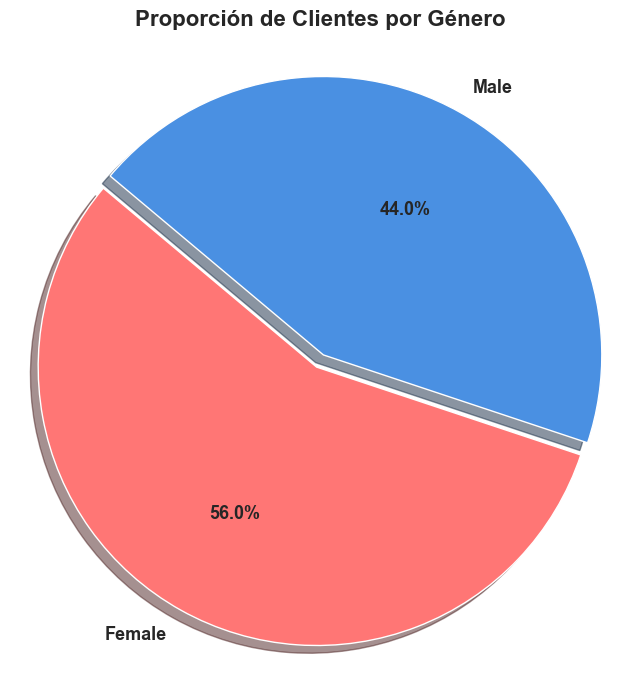

Conteo exacto por género:
Gender
Female    112
Male       88
Name: count, dtype: int64


In [15]:
# 1. Calcular la frecuencia de cada género
gender_counts = df['Gender'].value_counts()

# 2. Definir colores consistentes (Azul para Male, Rosado para Female)
# Usamos un diccionario para asegurar que el color corresponda a la etiqueta correcta
colors_map = {'Male': '#4a90e2', 'Female': '#ff7675'}
pie_colors = [colors_map[label] for label in gender_counts.index]

# 3. Configurar el lienzo
plt.figure(figsize=(8, 8))

# 4. Crear el gráfico de pastel
plt.pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=pie_colors,
    explode=(0.05, 0), # Resalta ligeramente la porción mayor
    shadow=True,
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)

plt.title('Proporción de Clientes por Género', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal') # Asegura que el gráfico sea un círculo perfecto
plt.show()

# Mostrar el conteo exacto debajo de la gráfica
print("Conteo exacto por género:")
print(gender_counts)

## 7. ¿Qué grupos de edad gastan más en promedio?

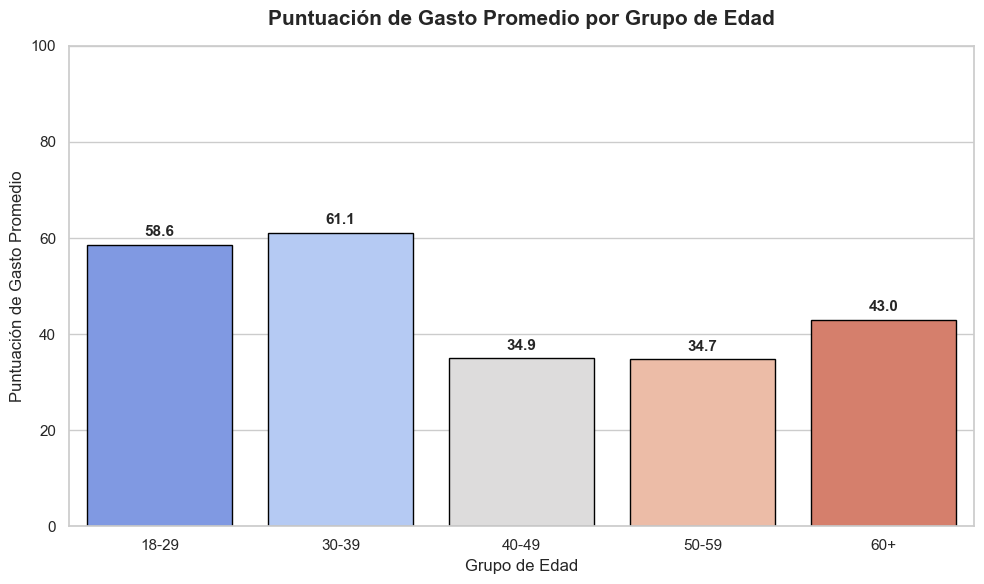

In [17]:
# 1. Definir los rangos de edad y etiquetas
# Usamos cortes en 30, 40, 50 y 60 para segmentar por décadas
age_bins = [18, 30, 40, 50, 60, 100]
age_labels = ['18-29', '30-39', '40-49', '50-59', '60+']

# 2. Crear la columna temporal de grupos de edad
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# 3. Calcular el promedio de gasto por grupo
avg_spending_age = df.groupby('Age_Group')['Spending Score (1-100)'].mean().reset_index()

# 4. Configurar el lienzo de la gráfica
plt.figure(figsize=(10, 6))

# 5. Crear la gráfica de barras
barplot = sns.barplot(
    data=avg_spending_age, 
    x='Age_Group', 
    y='Spending Score (1-100)', 
    palette='coolwarm',
    edgecolor='black'
)

# Añadir los valores exactos sobre cada barra para mayor claridad
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.1f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

# Títulos y etiquetas
plt.title('Puntuación de Gasto Promedio por Grupo de Edad', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Puntuación de Gasto Promedio', fontsize=12)
plt.ylim(0, 100) # Mantener la escala original del score

plt.tight_layout()
plt.show()

# Eliminar la columna temporal
df.drop(columns=['Age_Group'], inplace=True)

## 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?

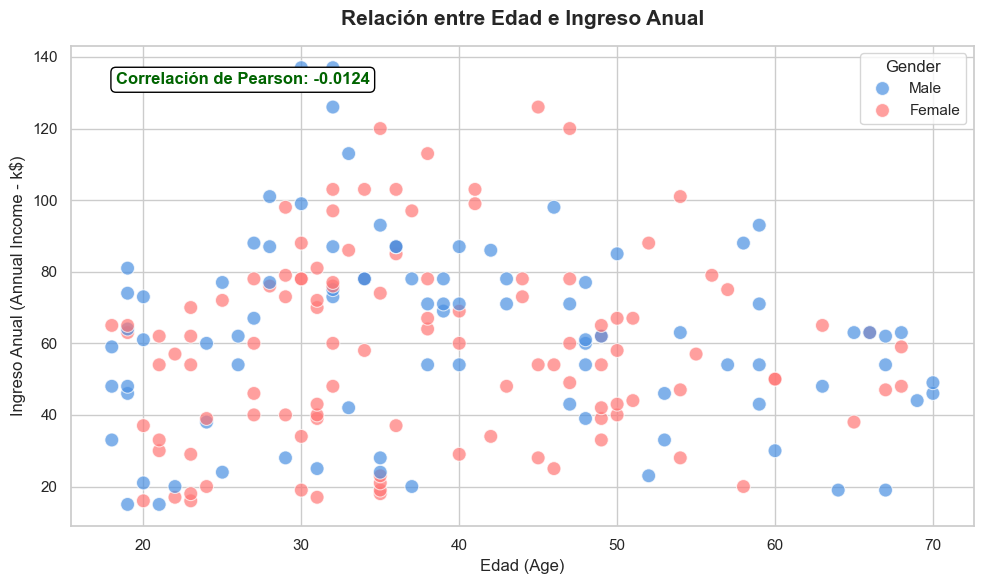

El coeficiente de correlación entre Edad e Ingreso es: -0.0124


In [18]:
# 1. Calcular el coeficiente de correlación de Pearson
correlation_age_income = df['Age'].corr(df['Annual Income (k$)'])

# 2. Configurar el lienzo de la gráfica
plt.figure(figsize=(10, 6))

# 3. Crear el gráfico de dispersión
sns.scatterplot(
    data=df, 
    x='Age', 
    y='Annual Income (k$)', 
    hue='Gender', 
    palette={'Male': '#4a90e2', 'Female': '#ff7675'}, 
    alpha=0.7, 
    s=100
)

# 4. Añadir títulos y etiquetas
plt.title('Relación entre Edad e Ingreso Anual', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Ingreso Anual (Annual Income - k$)', fontsize=12)

# 5. Mostrar el coeficiente de correlación en el gráfico
plt.annotate(f'Correlación de Pearson: {correlation_age_income:.4f}', 
             xy=(0.05, 0.92), xycoords='axes fraction', 
             fontsize=12, fontweight='bold', color='darkgreen',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.tight_layout()
plt.show()

print(f"El coeficiente de correlación entre Edad e Ingreso es: {correlation_age_income:.4f}")

## 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?

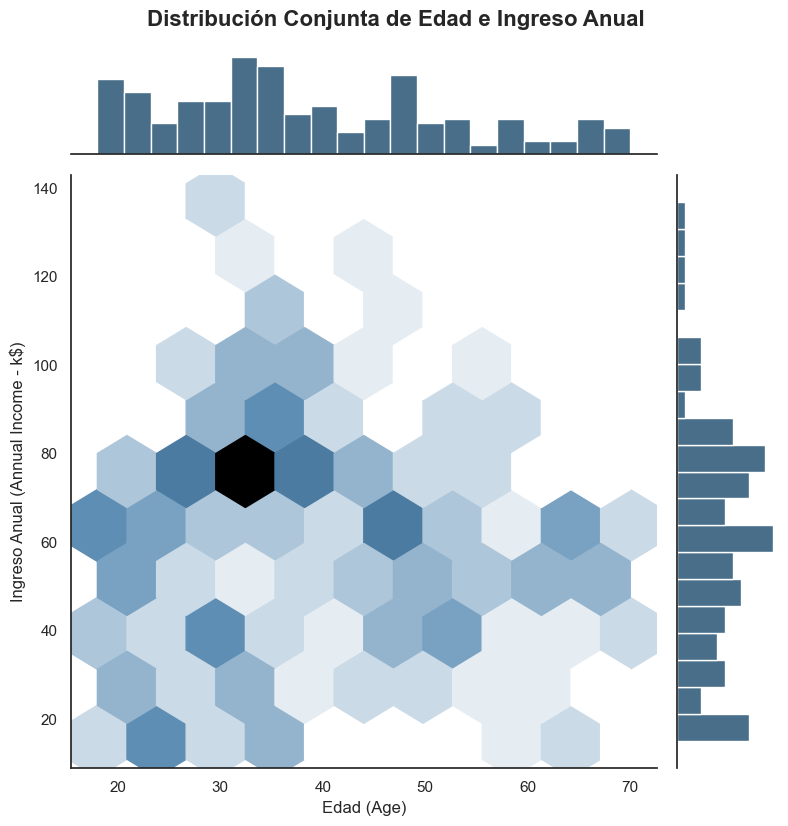

In [19]:
# Configurar el estilo visual
sns.set_theme(style='white')

# Crear un jointplot con tipo 'hex' para mostrar la densidad de la distribución conjunta
joint_plot = sns.jointplot(
    data=df, 
    x='Age', 
    y='Annual Income (k$)', 
    kind='hex', 
    color='#3c6382',
    height=8,
    marginal_kws=dict(bins=20, fill=True, color='#0a3d62')
)

# Ajustar títulos y etiquetas del gráfico principal y los marginales
joint_plot.fig.suptitle('Distribución Conjunta de Edad e Ingreso Anual', fontsize=16, fontweight='bold', y=1.03)
joint_plot.ax_joint.set_xlabel('Edad (Age)', fontsize=12)
joint_plot.ax_joint.set_ylabel('Ingreso Anual (Annual Income - k$)', fontsize=12)

plt.show()

## 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?

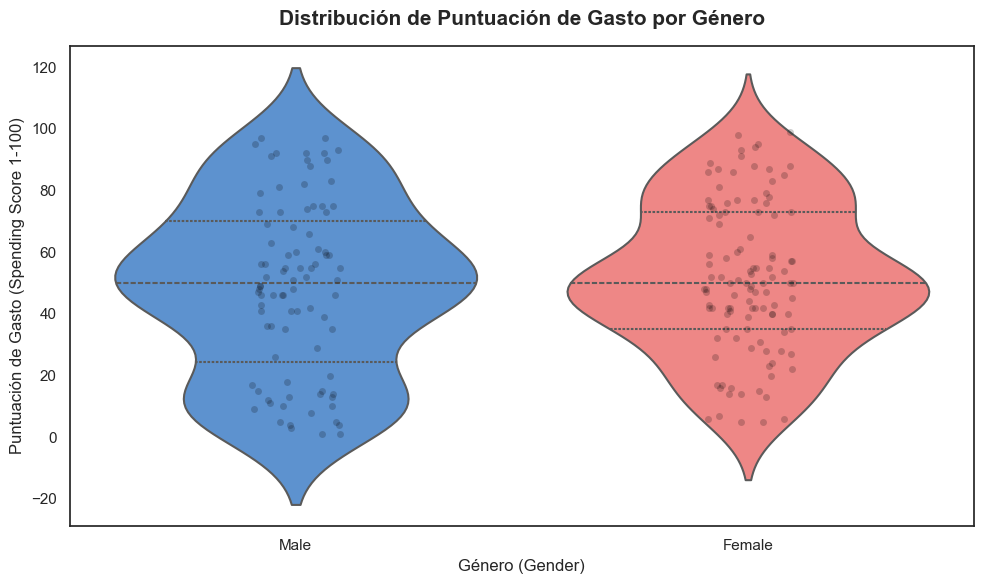

Estadísticas de gasto por género:
         mean  median    std
Gender                      
Female  51.53    50.0  24.11
Male    48.51    50.0  27.90


In [20]:
# 1. Configurar el lienzo de la gráfica
plt.figure(figsize=(10, 6))

# 2. Crear el gráfico de violín
# Usamos inner='quartile' para mostrar la mediana y los cuartiles dentro del violín
sns.violinplot(
    data=df, 
    x='Gender', 
    y='Spending Score (1-100)', 
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    inner='quartile',
    linewidth=1.5
)

# 3. Superponer un stripplot para observar la densidad de puntos individuales
sns.stripplot(
    data=df, 
    x='Gender', 
    y='Spending Score (1-100)', 
    color='black', 
    alpha=0.2, 
    jitter=True
)

# 4. Títulos y etiquetas
plt.title('Distribución de Puntuación de Gasto por Género', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Género (Gender)', fontsize=12)
plt.ylabel('Puntuación de Gasto (Spending Score 1-100)', fontsize=12)

plt.tight_layout()
plt.show()

# 5. Calcular estadísticas descriptivas para el análisis
spending_stats = df.groupby('Gender')['Spending Score (1-100)'].agg(['mean', 'median', 'std']).round(2)
print("Estadísticas de gasto por género:")
print(spending_stats)